# Audio Fingerprinting with Short-Time Fourier Transforms

This project initially began as a course assignment for ECE 2720: Combined Data Science for Engineers (Spring 2026).

This version is reworked, and will be substantially reworked and extended as an independent project, with a focus on developing an implementation suitable for eventual FPGA acceleration.


In [ ]:
import numpy as np
import sounddevice as sd
import matplotlib.pyplot as plt
from scipy.signal import stft

In [ ]:
AUDIO_DURATION = 4
SAMPLE_RATE = 16000
# NOISE_LEVEL = 0
# FFT_SIZE = 0
# HOP_SIZE

In [1]:
def record_audio(duration=audio_duration, fs =sample_rate):
    print("Recording Audio")
    x = sd.rec(int(duration * fs), samplerate = fs, channels = 1, dtype = 'float32')
    sd.wait()
    print("Done.")
    return x[: ,0], fs

# Record clean and noisy versions
x_clean , fs = record_audio()
x_noisy , _ = record_audio()

Recording...
Done.
Recording...
Done.


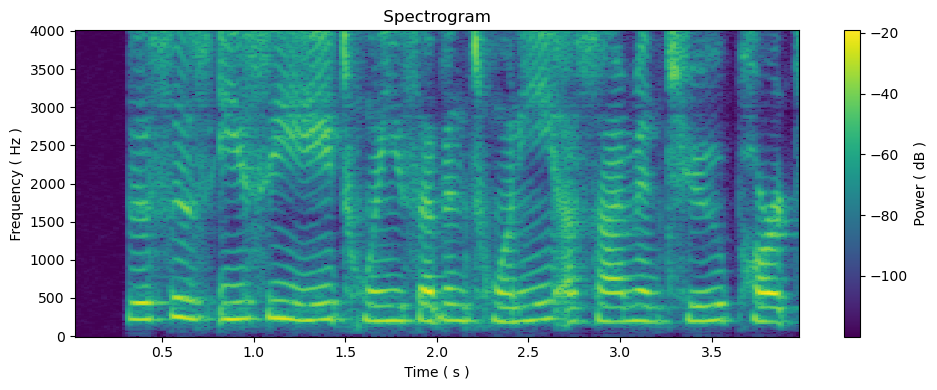

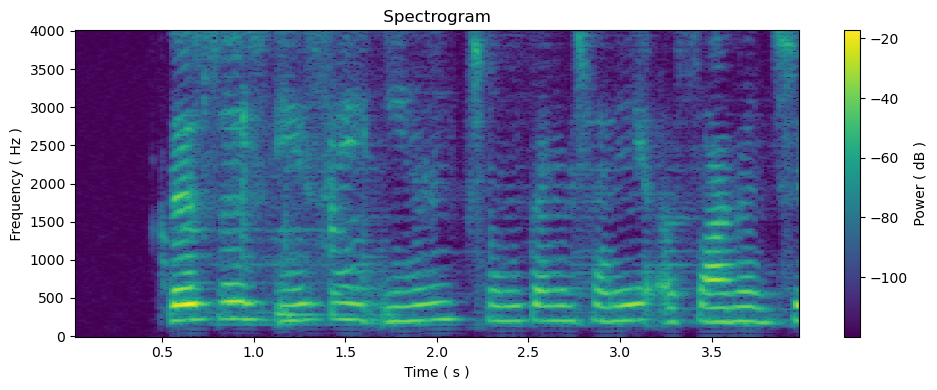

In [2]:
def compute_spectrogram(x, fs, nperseg =1024, noverlap =768, nfft =1024):
    f, t, Zxx = stft(
        x,
        fs = fs,
        window = "hann",
        nperseg = nperseg,
        noverlap = noverlap,
        nfft = nfft,
        boundary = None,
        padded = False
    )
    
    S = np.abs(Zxx) ** 2
    
# Restrict spectrogram to frequencies <= 4 kHz (focus on human voice range)
    freq_mask = f <= 4000
    f = f[freq_mask] # keep only frequencies <= 4 kHz
    S = S[freq_mask,:] # filter rows ( frequency axis )
    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
    return f , t , S

    
def plot_spectrogram(S , f , t) :
    plt.figure(figsize=(10 , 4) )
    S_db = 10*np.log10(S + 1e-12)
    plt.pcolormesh(t , f , S_db , shading = "auto")
    plt.colorbar(label = " Power ( dB ) ")
    plt.xlabel(" Time ( s ) ")
    plt.ylabel(" Frequency ( Hz ) ")
    plt.title(" Spectrogram ")
    plt.tight_layout()
    plt.show()

    
nperseg = 1024
noverlap = 768
f1 , t1 , S1 = compute_spectrogram(x_clean, fs, nperseg, noverlap)
f2 , t2 , S2 = compute_spectrogram(x_noisy, fs, nperseg, noverlap)
plot_spectrogram( S1 , f1 , t1 )
plot_spectrogram( S2 , f2 , t2 )

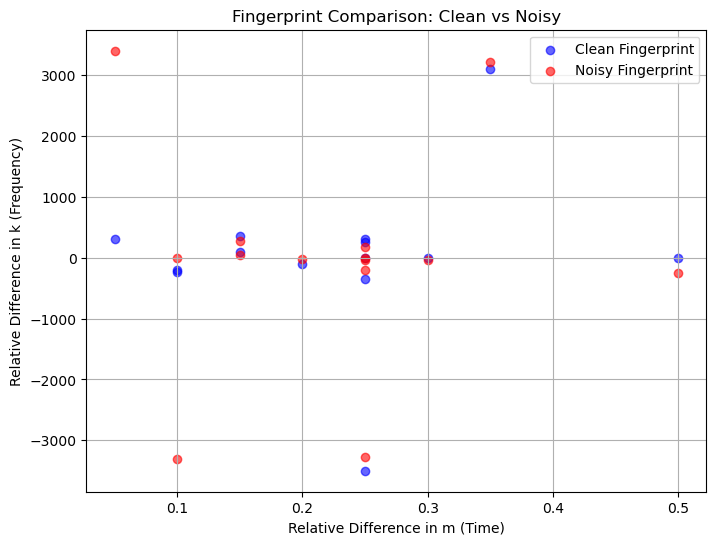

In [7]:
# Manually Extracted Peaks from Observations
clean_peaks = [[0.6, 490], [0.7, 250], [1, 250], [1.25, 250], [1.9, 600], 
               [2.25, 3700], [2.5, 200], [2.75, 500], [2.9, 600], [3.1, 500], 
               [3.25, 600], [3.5, 250], [3.75, 500], [2.8, 800], [1.75, 250]]

noisy_peaks = [[0.6, 490], [0.7, 480], [1, 450], [1.25, 450], [1.9, 480], 
               [2.25, 3700], [2.5, 430], [2.75, 400], [2.9, 500], [3.1, 480], 
               [3.25, 520], [3.5, 700], [3.75, 490], [2.8, 3800], [1.75, 200]]

# Fingerprint Construction
def construct_Fingerprint(peaks):

    # Convert to numpy list for sorting by time
    peaks = np.array(peaks)
    peaks = peaks[np.argsort(peaks[:, 0])]
    
    relative_diff = np.diff(peaks, axis=0) # this calculates the differences between each pair of m and k
    
    return relative_diff

clean_fingerprint = construct_Fingerprint(clean_peaks)
noisy_fingerprint = construct_Fingerprint(noisy_peaks)

# Plot Chart to compare fingerprints
plt.figure(figsize=(8, 6))
# X-axis is Delta m and Y-axis is Delta k
plt.scatter(clean_fingerprint[:, 0], clean_fingerprint[:, 1], c='blue', label='Clean Fingerprint', alpha=0.6)
plt.scatter(noisy_fingerprint[:, 0], noisy_fingerprint[:, 1], c='red', marker='o', label='Noisy Fingerprint', alpha=0.6)

plt.xlabel('Relative Difference in m (Time)')
plt.ylabel('Relative Difference in k (Frequency)')
plt.title('Fingerprint Comparison: Clean vs Noisy')
plt.legend()
plt.grid(True)
plt.show()